# Transformers for Gravitational-Wave Signal vs. Glitch Classification

## IMPRS Lecture Week 2026

---

In this tutorial we build a small **Transformer encoder** (in the Vision-Transformer style) that reads a one-detector whitened frequency-domain strain and decides whether it contains a **compact-binary-coalescence (CBC) chirp** or a **scattered-light glitch**.

This is a simplified version of a real data-quality problem. LIGO/Virgo/KAGRA data streams are full of short, non-Gaussian transients (called *glitches*) that look superficially like astrophysical signals but are instrumental. One of the most common, and one of the easiest to describe analytically, is **scattered light**: stray laser light bounces off a moving surface (a suspension, a baffle) and reimprints on the main beam with a Doppler-modulated phase. In a time–frequency view this shows up as an **arch** that rises and then falls as the scattering surface decelerates and reverses.

We use a **Transformer** rather than a MLP because the transformer is a natural fit for sequential data where the *relationships* between parts of the signal matter. A chirp has a very specific time–frequency structure — frequency sweeping upward monotonically, amplitude growing — while a scattered-light glitch is localised with an arch-shaped track. Attention lets the model compare every patch of the (frequency-domain) waveform to every other patch in one step.

We also deliberately make the task **hard**: the signal-to-noise ratio is fixed at $\rho = 6$ (below LIGO's single-detector detection threshold of 8), and we push the scattered-light arch's peak frequency up into the chirp band, so the classifier can't just threshold on energy or on a single frequency band. It has to use signal morphology.

### Steps

1. **Simulate the signals** using the same pipeline as the normalizing-flow tutorial: IMRPhenomPv2 via `lalsimulation` for CBC chirps, and a toy analytic scattered-light arch for glitches, all whitened with the aLIGO ZeroDetHighPower PSD.
2. **Package** the data into a PyTorch `Dataset` / `DataLoader` that adds a fresh noise realisation on every draw.
3. **Build a Transformer classifier** from scratch: patch embedding → learned positional encoding → encoder layers → mean-pool → linear head.
4. **Train** with cross-entropy for 20 epochs.
5. **Evaluate** — accuracy, confusion matrix, ROC curve.
6. **Peek inside** — visualise which frequency patches the network attends to, alongside the clean signal it's trying to identify.

### Exercises

1. Add a second glitch morphology (sine-Gaussian, blip, etc.) and turn this into a 3-way classifier.
2. Replace the learned positional encoding with the classical sinusoidal one from *Attention Is All You Need*. Does it matter?
3. Lower the target SNR further until the model breaks. Or raise it back up to 15 — what happens to the attention map?
4. Swap the Transformer for a 1-D CNN with a comparable parameter count. Which wins?
5. Add a learnable "CLS" token at position 0 (ViT-style) and read the classification off *that* instead of the mean-pool. Compare.

## Imports

In [211]:
# If using colab, install appropriate packages.
!pip install lalsuite

In [212]:
import numpy as np
import matplotlib.pyplot as plt

import lal
import lalsimulation as LS

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

In [213]:
if torch.backends.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print(f"Using device: {device}")

torch.manual_seed(0)
np.random.seed(0)

Using device: cpu


## Signal model and noise PSD

We work with 2-second segments at a sampling rate of $f_s = 1024\,\mathrm{Hz}$, giving $N_t = 2048$ time-domain samples or equivalently $n_f = 1025$ frequency bins from 0 to $f_{\max} = 512\,\mathrm{Hz}$ at $\Delta f = 0.5\,\mathrm{Hz}$. These numbers match the normalizing-flow tutorial so we can reuse its waveform generation almost verbatim.

The noise model is stationary Gaussian, with the **aLIGO ZeroDetHighPower** design power-spectral density. After whitening by the ASD, noise in each frequency bin is complex Gaussian with unit-variance real and imaginary parts — this is the representation the network trains on.

In [214]:
# Waveform / sampling configuration
approximant = 'IMRPhenomPv2'
f_min = 20.0
f_max = 512.0
T = 2.0

delta_f = 1 / T                       # 0.5 Hz
nf = int(f_max / delta_f) + 1         # 1025 frequency bins
fs = int(2 * f_max)                   # 1024 Hz time-domain sampling rate
N_t = int(T * fs)                     # 2048 time-domain samples

f_array = np.linspace(0.0, f_max, num=nf)
t_array = np.arange(N_t) / fs         # time axis, used for the glitches

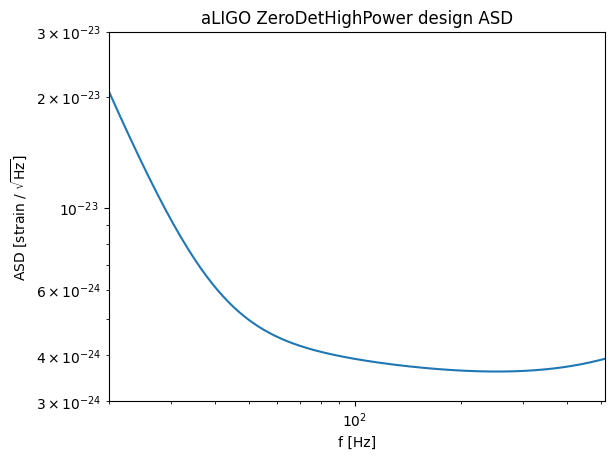

In [215]:
# Generate the noise PSD. LIGO design sensitivity (zero-detuning, high power).

lalseries = lal.CreateREAL8FrequencySeries(
    '', lal.LIGOTimeGPS(0), 0, delta_f, lal.DimensionlessUnit, nf,
)
LS.SimNoisePSD(lalseries, 0, LS.SimNoisePSDaLIGOZeroDetHighPowerPtr)
psd = lalseries.data.data.copy()
psd[:int(f_min / delta_f)] = 1.0      # avoid division by zero below f_min
psd[-1] = psd[-2]
asd = np.sqrt(psd)

plt.plot(f_array, asd)
plt.xlim((f_min, f_max)); plt.ylim((3e-24, 3e-23))
plt.xscale('log'); plt.yscale('log')
plt.xlabel('f [Hz]'); plt.ylabel('ASD [strain / $\\sqrt{\\mathrm{Hz}}$]')
plt.title('aLIGO ZeroDetHighPower design ASD')
plt.show()

### Class 0 — CBC chirps from IMRPhenomPv2

Generation follows the normalizing-flow tutorial: we vary only the component masses $(m_1, m_2)$ on a uniform $[20, 80]\,M_\odot$ prior, hold everything else fixed (face-on, 1 Gpc, zero spins), and call `SimInspiralFD` to get the plus polarisation in the frequency domain. The `time_shift` places the merger in a consistent place in the buffer so the network doesn't have to learn trivial translations.

Each waveform is then **whitened**,
$$
\tilde h_\mathrm{white}(f) = \sqrt{4 \Delta f}\, \frac{\tilde h(f)}{\mathrm{ASD}(f)},
$$
and frequencies below $f_{min}$ are zeroed out. In this representation a unit-PSD noise realisation has real and imaginary parts of each bin distributed as $\mathcal N(0,1)$.

In [216]:
num_per_class = 2000    # reduce if generation/training is too slow on your machine

m_lower, m_upper = 20.0, 80.0
masses = m_lower + np.random.random((num_per_class, 2)) * (m_upper - m_lower)
masses = np.sort(masses, axis=-1)[:, ::-1]   # ensure m1 >= m2

# Fixed extrinsic parameters
distance = 1000.0   # Mpc
inclination = 0.0
spin = (0.0,) * 6
phase = 0.0
approximant_lal = LS.GetApproximantFromString(approximant)

In [217]:
chirps_fd = np.zeros((num_per_class, nf), dtype=np.complex128)

for i in range(num_per_class):
    m1, m2 = masses[i]
    hp, _ = LS.SimInspiralFD(
        m1 * lal.MSUN_SI, m2 * lal.MSUN_SI,
        *spin,
        distance * 1e6 * lal.PC_SI, inclination, phase,
        0.0, 0.0, 0.0,              # longAscNodes, eccentricity, meanPerAno
        delta_f, f_min, f_max, 20.0, # f_ref
        None,
        approximant_lal,
    )

    # Align the merger consistently across the buffer.
    dt = 1 / hp.deltaF + (hp.epoch.gpsSeconds + hp.epoch.gpsNanoSeconds * 1e-9)
    time_shift = np.exp(-1j * 2 * np.pi * dt * f_array)
    h = hp.data.data * time_shift

    # Whiten.
    h[:int(f_min / delta_f)] = 0.0
    h = h / asd * np.sqrt(4.0 * delta_f)
    chirps_fd[i] = h

print("chirps shape:", chirps_fd.shape, chirps_fd.dtype)

chirps shape: (2000, 1025) complex128


### Class 1 — scattered-light glitches

We model the scattered-light arch as a toy analytic waveform in the **time domain** and then FFT and whiten it with the same ASD as the chirps, so that chirps and glitches live in identical preprocessing space.

The key feature is that the instantaneous frequency is **not monotonic**: it rises and then falls (an *arch*) as the scattering surface decelerates and reverses. 


Question for class: How do you predict that the network will differentiate the two signals? 

In [218]:
def generate_scattered_light(t):
    t0 = np.random.uniform(0.3 * T, 0.6 * T)
    duration = np.random.uniform(0.2, 0.5)
    # Push f_peak up into the chirp band so the two classes overlap in frequency.
    # A classifier that just sums energy below 50 Hz cannot solve this.
    f_peak = np.random.uniform(30, 80)
    u = (t - t0) / duration
    mask = (u > 0) & (u < 1)
    # Arch: instantaneous frequency goes up then back down.
    f_inst = np.where(mask, f_peak * np.sin(np.pi * u), 0.0)
    dt = t[1] - t[0]
    phase = 2 * np.pi * np.cumsum(f_inst) * dt
    env = np.where(mask, np.sin(np.pi * u) ** 2, 0.0)
    return env * np.sin(phase)

In [219]:
# Generate glitches in the time domain, then FFT to match the chirp grid and whiten.

glitches_fd = np.zeros((num_per_class, nf), dtype=np.complex128)

dt_td = 1 / fs
for i in range(num_per_class):
    h_td = generate_scattered_light(t_array)

    # FFT convention matching lalsim: h(f) = integral h(t) e^{-2 pi i f t} dt ~= rfft(h) * dt
    h_fd = np.fft.rfft(h_td) * dt_td

    # Whiten the same way as the chirps.
    h_fd[:int(f_min / delta_f)] = 0.0
    h_fd = h_fd / asd * np.sqrt(4.0 * delta_f)
    glitches_fd[i] = h_fd

print("glitches shape:", glitches_fd.shape)

glitches shape: (2000, 1025)


### Two-channel tensor and SNR normalisation

We'll feed the network a **two-channel** (real, imaginary) tensor of shape $(2, 1024)$ — we drop the Nyquist bin to get a power-of-two length that patches cleanly. Each example is then rescaled so that its whitened optimal SNR,
$$
\rho^2 = \sum_f \big[\tilde h_\mathrm{w}(f)\big]^2 \cdot 2,
$$
equals a common target. We pick $\rho = 6$ — well below LIGO's detection threshold of 8 for a single detector — to make the task genuinely hard. At $\rho = 6$ the signal buries into the noise in any single patch, and the classifier has to integrate information from several patches to decide. Crucially, the SNR is the **same** for both classes, so the network cannot cheat by thresholding on total energy.

In [220]:
def to_two_channel(h_fd):
    '''Drop the Nyquist bin and split complex -> (real, imag) channels.'''
    # Keep float64 for now — glitches divided by ASD ~1e-23 give huge values that would
    # overflow when squared in float32. We cast down after SNR normalisation.
    return np.stack([h_fd.real[:, :1024], h_fd.imag[:, :1024]], axis=1)

chirps_data = to_two_channel(chirps_fd)
glitches_data = to_two_channel(glitches_fd)
print("per-example shape:", chirps_data.shape[1:])


target_snr = 6.0

def normalise_to_snr(X, rho):
    # Optimal SNR^2 in the whitened representation is sum(h^2) (real + imag parts), for each example.
    snr = np.sqrt((X ** 2).sum(axis=(1, 2), keepdims=True))
    return (X / (snr + 1e-12) * rho).astype(np.float32)

chirps_data = normalise_to_snr(chirps_data, target_snr)
glitches_data = normalise_to_snr(glitches_data, target_snr)

signals = np.concatenate([chirps_data, glitches_data], axis=0)
labels = np.concatenate([
    np.zeros(num_per_class, dtype=np.int64),   # 0 = chirp
    np.ones(num_per_class, dtype=np.int64),    # 1 = glitch
])
print("signals shape:", signals.shape, "  labels shape:", labels.shape)

per-example shape: (2, 1024)
signals shape: (4000, 2, 1024)   labels shape: (4000,)


### A first look at the data

To understand what the network sees, it's useful to plot the clean whitened signals in **both** time and frequency. The time-domain view comes from an inverse FFT of the whitened spectrum — it's not a physical strain, but it makes the chirp's frequency sweep and the glitch's localisation obvious.

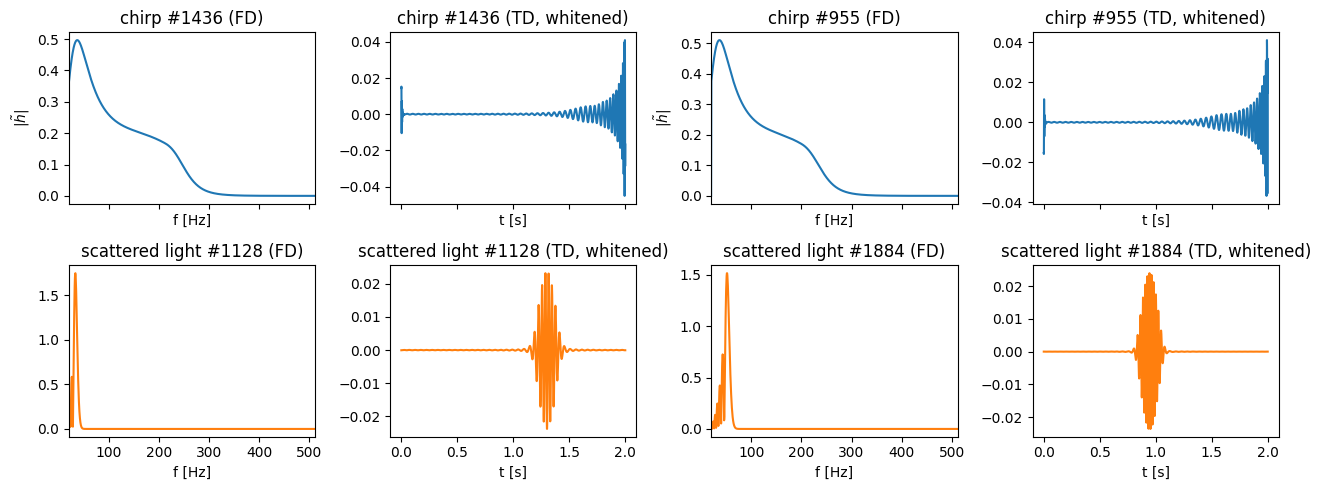

In [221]:
def fd_to_td(h_2ch):
    '''Invert the whitened 2-channel FD representation back to the time domain.'''
    h_complex = h_2ch[0] + 1j * h_2ch[1]
    # Put the Nyquist bin back (as zero) so irfft gives the right length.
    padded = np.zeros(nf, dtype=complex)
    padded[:1024] = h_complex
    return np.fft.irfft(padded, n=N_t)


fig, axes = plt.subplots(2, 4, figsize=(13, 5), sharex='col')
for col in range(2):
    i = np.random.randint(num_per_class)
    axes[0, 2 * col].plot(f_array[:1024], np.abs(chirps_data[i, 0] + 1j * chirps_data[i, 1]))
    axes[0, 2 * col].set_title(f'chirp #{i} (FD)')
    axes[0, 2 * col].set_xlabel('f [Hz]'); axes[0, 2 * col].set_ylabel('|$\\tilde h$|')
    axes[0, 2 * col].set_xlim((f_min, f_max))

    axes[0, 2 * col + 1].plot(t_array, fd_to_td(chirps_data[i]))
    axes[0, 2 * col + 1].set_title(f'chirp #{i} (TD, whitened)')
    axes[0, 2 * col + 1].set_xlabel('t [s]')

    j = np.random.randint(num_per_class)
    axes[1, 2 * col].plot(f_array[:1024], np.abs(glitches_data[j, 0] + 1j * glitches_data[j, 1]), color='C1')
    axes[1, 2 * col].set_title(f'scattered light #{j} (FD)')
    axes[1, 2 * col].set_xlabel('f [Hz]'); axes[1, 2 * col].set_xlim((f_min, f_max))

    axes[1, 2 * col + 1].plot(t_array, fd_to_td(glitches_data[j]), color='C1')
    axes[1, 2 * col + 1].set_title(f'scattered light #{j} (TD, whitened)')
    axes[1, 2 * col + 1].set_xlabel('t [s]')

plt.tight_layout(); plt.show()

### Package into a PyTorch `Dataset`

In [222]:
class SignalGlitchDataset(Dataset):

    def __init__(self, signals, labels):
        self.signals = torch.tensor(signals)     # (N, 2, 1024)
        self.labels = torch.tensor(labels)       # (N,)

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        signal = self.signals[idx]
        noise = torch.randn_like(signal)
        return signal + noise, self.labels[idx]


dataset = SignalGlitchDataset(signals, labels)

train_fraction = 0.8
num_total = len(dataset)
num_train = int(round(train_fraction * num_total))
num_test = num_total - num_train
train_dataset, test_dataset = random_split(dataset, [num_train, num_test])

train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

x_batch, y_batch = next(iter(train_dataloader))
print("x_batch shape:", x_batch.shape, "  y_batch shape:", y_batch.shape)

x_batch shape: torch.Size([64, 2, 1024])   y_batch shape: torch.Size([64])


## The Transformer

A Transformer encoder takes a sequence of $L$ vectors $x_1, \dots, x_L$ (each in $\mathbb{R}^{d}$) and outputs a new sequence of the same shape. Each output position is a context-aware mixture of *all* input positions, computed by **self-attention**.

### Self-attention in one equation

Given queries $Q$, keys $K$, values $V$ (all produced from the input by learned linear projections),
$$
\mathrm{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{Q K^\top}{\sqrt{d_k}}\right) V.
$$
Row $i$ of $QK^\top / \sqrt{d_k}$ scores how much position $i$ should attend to every other position; softmax turns it into a distribution; and the output at $i$ is the corresponding weighted sum of value vectors.

### Two choices we need to make

1. **Tokenisation.** Treating each of 1024 frequency bins as its own token would be expensive (attention cost is $O(L^2)$). We split the two-channel signal along the frequency axis into non-overlapping patches of size `patch_size = 32` — giving $L = 32$ tokens. A 1-D convolution with stride equal to kernel size does the patching and the linear projection to dimension $d = 64$ in one go.
2. **Position information.** Self-attention is permutation-equivariant: it has no idea which patch came first. The simplest fix is to **stash the patch index** $(0, 1, 2, \dots, L-1)$ into one coordinate of each token — that tag is enough to break the symmetry so attention can tell patches apart. (Real transformers use learned vectors or sinusoids; this is the no-frills version.)

After the encoder we have $L$ context-aware patch embeddings. To get a single vector for classification, we just **mean-pool** across the sequence and apply a linear head.

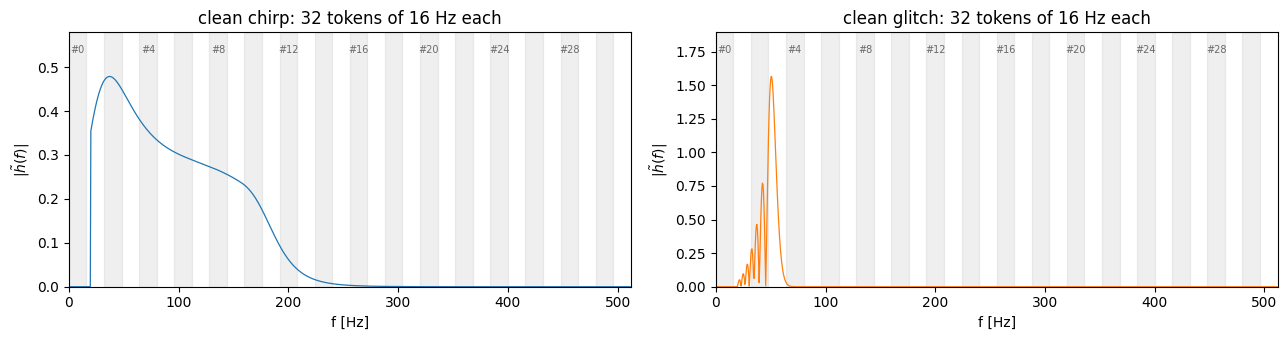

In [223]:
# Visualise the token layout: each patch is a 16 Hz band in the frequency domain.
# We shade alternating patches and annotate every 4th one with its patch index.

patch_size = 32                             # frequency bins per patch
num_patches = 1024 // patch_size            # = 32 tokens
patch_boundaries = np.arange(num_patches + 1) * patch_size * delta_f   # Hz

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, (title, data, color) in zip(axes, [
    ('clean chirp', chirps_data, 'C0'),
    ('clean glitch', glitches_data, 'C1'),
]):
    i = np.random.randint(num_per_class)
    h_abs = np.abs(data[i, 0] + 1j * data[i, 1])
    ax.plot(f_array[:1024], h_abs, color=color, lw=0.9)

    y_top = h_abs.max() * 1.1
    for p in range(num_patches):
        if p % 2 == 0:          # shade every other patch
            ax.axvspan(patch_boundaries[p], patch_boundaries[p + 1],
                       color='grey', alpha=0.12, zorder=0)
        if p % 4 == 0:          # annotate every 4th patch index
            ax.text((patch_boundaries[p] + patch_boundaries[p + 1]) / 2,
                    y_top, f'#{p}', ha='center', va='bottom',
                    fontsize=7, color='dimgrey')

    ax.set_xlim((0, f_max)); ax.set_ylim(0, y_top * 1.1)
    ax.set_xlabel('f [Hz]'); ax.set_ylabel('|$\\tilde h(f)$|')
    ax.set_title(f'{title}: {num_patches} tokens of 16 Hz each')

plt.tight_layout(); plt.show()

In [224]:
class EncoderLayer(nn.Module):
    '''A minimal transformer encoder layer.

    Functionally equivalent to `nn.TransformerEncoderLayer` with post-norm, but
    written out explicitly so (a) the attention machinery is visible and
    (b) we can stash the attention weights as `self.last_attn` for later
    inspection without any hooks or monkey-patching.
    '''

    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead,
                                               dropout=dropout,
                                               batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.last_attn = None     # (B, L, L), filled in on every forward pass

    def forward(self, x):
        attn_out, attn_w = self.self_attn(x, x, x,
                                          need_weights=True,
                                          average_attn_weights=True)
        self.last_attn = attn_w.detach()
        x = self.norm1(x + self.dropout(attn_out))
        ff = self.linear2(self.dropout(torch.relu(self.linear1(x))))
        x = self.norm2(x + self.dropout(ff))
        return x


class TransformerClassifier(nn.Module):

    def __init__(self, num_freq=1024, patch_size=32, d_model=64,
                 num_layers=2, num_classes=2):
        super().__init__()
        num_patches = num_freq // patch_size
        self.patch_size = patch_size
        self.num_patches = num_patches

        # Patchify + project: a 1-D convolution with stride = kernel_size splits
        # the signal into non-overlapping patches and turns each patch into a
        # d_model-dim vector in a single operation.
        self.patch_embed = nn.Conv1d(2, d_model,
                                     kernel_size=patch_size,
                                     stride=patch_size)

        # Positional encoding: stash the patch index (0, 1, ..., L-1) into the
        # first coordinate of each token. Breaks the permutation symmetry of
        # attention so the model can tell one patch from another.
        pos = torch.zeros(num_patches, d_model)
        pos[:, 0] = torch.arange(num_patches, dtype=torch.float)
        self.register_buffer("positions", pos)

        self.encoder = nn.ModuleList([
            EncoderLayer(d_model, nhead=1, dim_feedforward=128)
            for _ in range(num_layers)
        ])
        self.head = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (B, 2, 1024) -> (B, D, L) -> (B, L, D)
        tokens = self.patch_embed(x).transpose(1, 2)
        tokens = tokens + self.positions             # add the position tag
        for layer in self.encoder:
            tokens = layer(tokens)                   # (B, L, D)
        return self.head(tokens.mean(dim=1))         # mean-pool + classify


model = TransformerClassifier().to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"model has {num_params:,} parameters")

model has 71,234 parameters


Sanity check: a single forward pass should produce logits of shape (batch, 2).

In [225]:
x_batch, y_batch = next(iter(train_dataloader))
logits = model(x_batch.to(device))
print("input shape :", x_batch.shape)
print("logits shape:", logits.shape)

input shape : torch.Size([64, 2, 1024])
logits shape: torch.Size([64, 2])


## Training

Two output logits → cross-entropy loss, Adam, 15 epochs. We track accuracy along with the loss because it's more interpretable for a classifier.

In [226]:
# compute the divergence between predicted probability and actual labels
# given (x, y) pairs it is 
# sum - y * log f(x)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)


def run_epoch(dataloader, model, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = loss_fn(logits, y)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_count += X.size(0)

    return total_loss / total_count, total_correct / total_count

In [227]:
epochs = 20
train_loss_hist, test_loss_hist = [], []
train_acc_hist,  test_acc_hist  = [], []

for ep in range(epochs):
    tr_loss, tr_acc = run_epoch(train_dataloader, model, loss_fn, optimizer)
    te_loss, te_acc = run_epoch(test_dataloader,  model, loss_fn, optimizer=None)

    train_loss_hist.append(tr_loss); test_loss_hist.append(te_loss)
    train_acc_hist.append(tr_acc);   test_acc_hist.append(te_acc)

    print(f"epoch {ep+1:>2d}   train loss {tr_loss:.4f}  acc {tr_acc:.3f}   "
          f"| test loss {te_loss:.4f}  acc {te_acc:.3f}")

print("Done!")

epoch  1   train loss 0.6934  acc 0.515   | test loss 0.7145  acc 0.495
epoch  2   train loss 0.6936  acc 0.522   | test loss 0.6767  acc 0.545
epoch  3   train loss 0.6140  acc 0.663   | test loss 0.5544  acc 0.715
epoch  4   train loss 0.5058  acc 0.763   | test loss 0.4537  acc 0.782
epoch  5   train loss 0.4443  acc 0.795   | test loss 0.4839  acc 0.781
epoch  6   train loss 0.4515  acc 0.787   | test loss 0.4616  acc 0.786
epoch  7   train loss 0.4511  acc 0.791   | test loss 0.4302  acc 0.805
epoch  8   train loss 0.4548  acc 0.789   | test loss 0.4472  acc 0.790
epoch  9   train loss 0.4338  acc 0.799   | test loss 0.3862  acc 0.825
epoch 10   train loss 0.4245  acc 0.818   | test loss 0.4006  acc 0.816
epoch 11   train loss 0.4343  acc 0.795   | test loss 0.4463  acc 0.785
epoch 12   train loss 0.4163  acc 0.816   | test loss 0.4170  acc 0.805
epoch 13   train loss 0.4143  acc 0.817   | test loss 0.4042  acc 0.809
epoch 14   train loss 0.3978  acc 0.816   | test loss 0.4044  ac

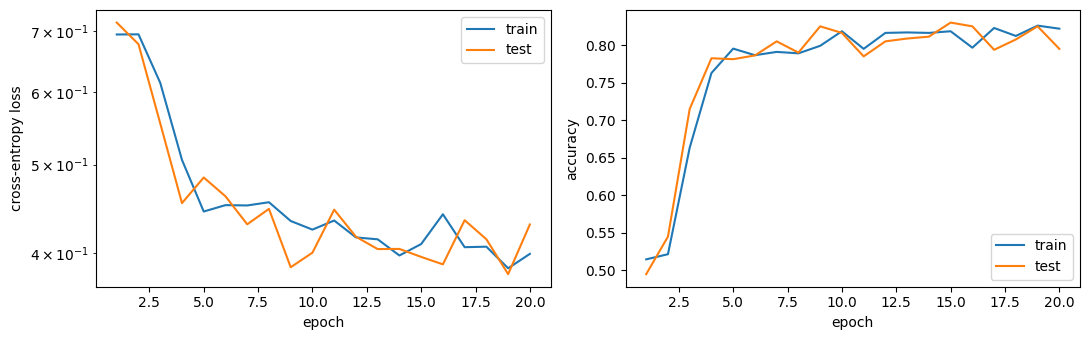

In [228]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
ep = np.arange(1, epochs + 1)
ax1.plot(ep, train_loss_hist, label='train'); ax1.plot(ep, test_loss_hist, label='test')
ax1.set_xlabel('epoch'); ax1.set_ylabel('cross-entropy loss'); ax1.set_yscale('log'); ax1.legend()
ax2.plot(ep, train_acc_hist, label='train'); ax2.plot(ep, test_acc_hist, label='test')
ax2.set_xlabel('epoch'); ax2.set_ylabel('accuracy'); ax2.legend()
plt.tight_layout(); plt.show()

## Evaluation

Three views of the trained classifier:

1. **Confusion matrix** — how often does each true class get called each predicted class?
2. **ROC curve** — as we sweep the decision threshold on the glitch probability, how do true-positive and false-positive rates trade off?
3. **Attention map** — for one chirp and one glitch example, which frequency patches does the network attend to in the final encoder layer?

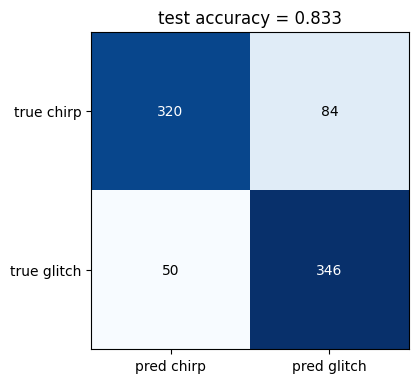

In [229]:
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for X, y in test_dataloader:
        X = X.to(device)
        all_logits.append(model(X).cpu())
        all_labels.append(y)
all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)
all_probs = torch.softmax(all_logits, dim=1)[:, 1].numpy()   # P(class = glitch)
all_preds = all_logits.argmax(dim=1).numpy()
all_true = all_labels.numpy()

# Confusion matrix (rows = true, cols = predicted)
cm = np.zeros((2, 2), dtype=int)
for t_, p_ in zip(all_true, all_preds):
    cm[t_, p_] += 1

fig, ax = plt.subplots(figsize=(4.2, 4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1], ['pred chirp', 'pred glitch'])
ax.set_yticks([0, 1], ['true chirp', 'true glitch'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
ax.set_title(f'test accuracy = {(all_preds == all_true).mean():.3f}')
plt.tight_layout(); plt.show()

### Looking inside: which patches does the network attend to?

Every encoder layer computes an attention matrix of shape $L \times L$, where row $i$ is the distribution over keys that query patch $i$ uses to gather information. Each patch covers 32 frequency bins, i.e. a 16 Hz band.

We visualise the **final** encoder layer's attention matrix directly as a heatmap. The axes are labelled in Hz (patch centre frequency), so reading along a row tells you, for a given query patch, which frequency bands the model pulls information from. Dark diagonals mean attention is mostly local; bright off-diagonal blocks mean the model is comparing distant frequency bands.

We look at the last layer rather than the first: early-layer attention tends to be fairly uniform (tokens haven't accumulated much context yet), while the final layer is where the model decides how to combine patches before the pooled readout.

Because our `EncoderLayer` stashes its attention weights as `self.last_attn` on every forward pass, we just run the model on one example and read `model.encoder[-1].last_attn` — no hooks, no monkey-patching. Alongside each attention heatmap we plot the **clean** signal (both TD and FD) that went into the noisy example, so you can match attention structure to waveform morphology.

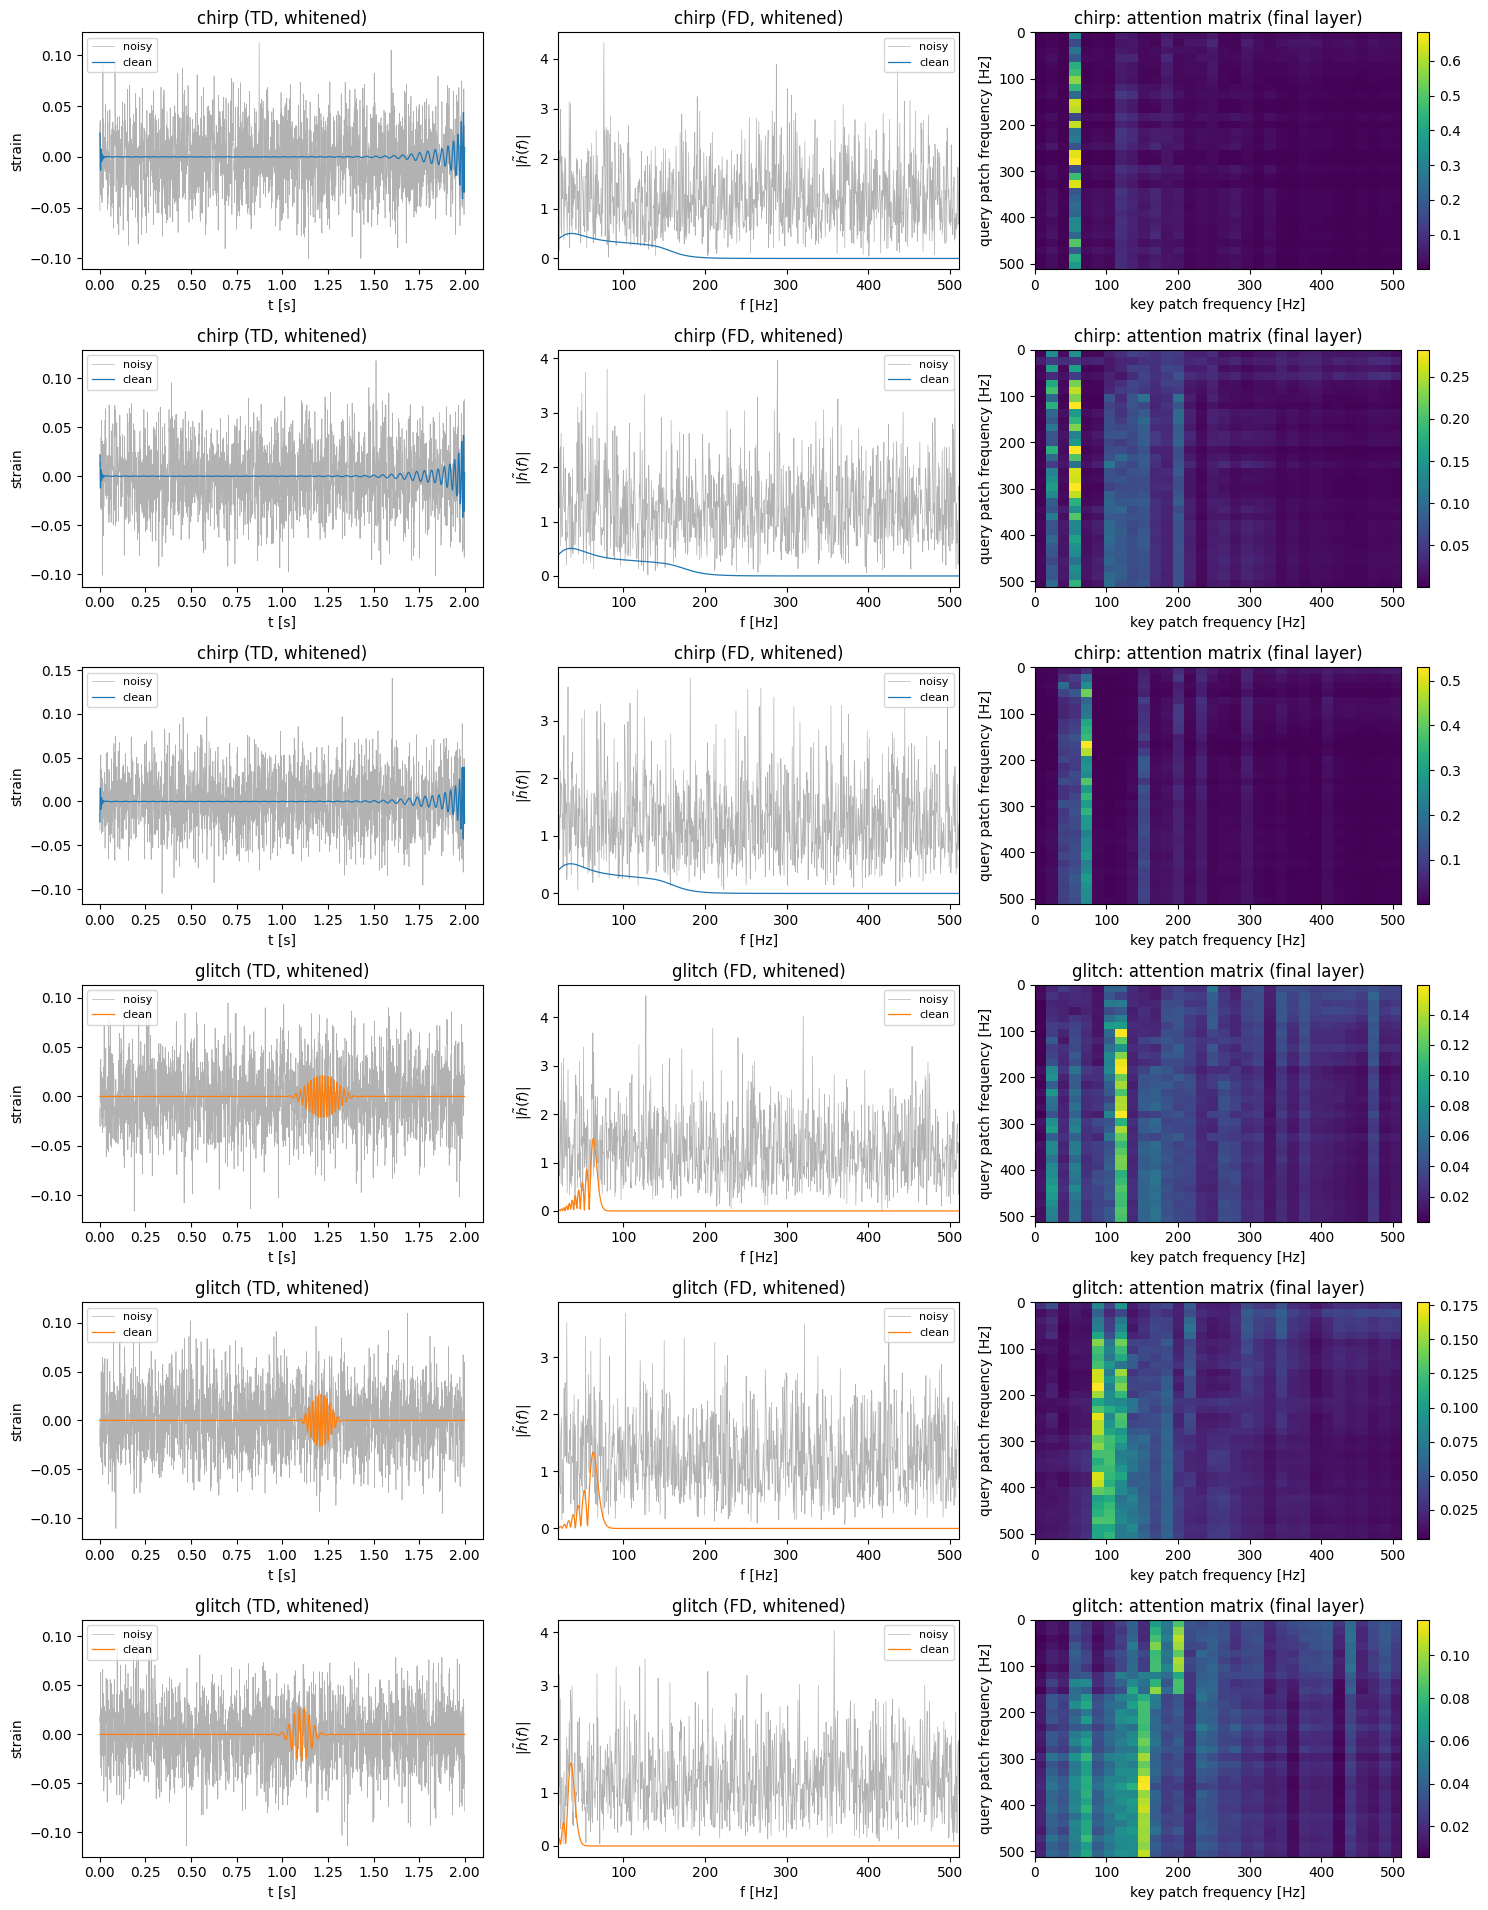

In [230]:
# Show a few correctly-classified examples of each class, so you can see
# whether the model's attention strategy is consistent across examples or
# varies from example to example.

num_examples_per_class = 3

# Re-iterate the test loader deterministically to recover the actual inputs and the underlying
# clean signals (from test_dataset.indices into the original signals array).
test_loader_inorder = DataLoader(test_dataset, batch_size=64, shuffle=False)
all_X = torch.cat([X for X, _ in test_loader_inorder])
test_indices = np.array(test_dataset.indices)   # mapping test-row -> row in `signals`

def clean_signal_for(test_row):
    return signals[test_indices[test_row]]      # shape (2, 1024)

correct_chirp_all  = [i for i in range(len(all_true))
                      if all_true[i] == 0 and all_preds[i] == 0]
correct_glitch_all = [i for i in range(len(all_true))
                      if all_true[i] == 1 and all_preds[i] == 1]

rng = np.random.default_rng(0)
chirp_idxs  = rng.choice(correct_chirp_all,  num_examples_per_class, replace=False)
glitch_idxs = rng.choice(correct_glitch_all, num_examples_per_class, replace=False)

examples = (
    [('chirp',  all_X[i], clean_signal_for(i)) for i in chirp_idxs] +
    [('glitch', all_X[i], clean_signal_for(i)) for i in glitch_idxs]
)

patch_size = model.patch_size
num_patches = model.num_patches

num_rows = len(examples)
fig, axes = plt.subplots(num_rows, 3, figsize=(15, 3.2 * num_rows))
for row, (name, x_noisy, x_clean) in enumerate(examples):

    # Forward pass — the final encoder layer stores its attention matrix as `last_attn`.
    with torch.no_grad():
        _ = model(x_noisy.unsqueeze(0).to(device))
    A = model.encoder[-1].last_attn[0].cpu().numpy()     # (L, L), head-averaged

    color = 'C0' if name == 'chirp' else 'C1'
    x_noisy_np = x_noisy.numpy()

    # ----- left: time domain, noisy (grey) behind clean (colour)
    ax_td = axes[row, 0]
    ax_td.plot(t_array, fd_to_td(x_noisy_np), color='grey', lw=0.5, alpha=0.6, label='noisy')
    ax_td.plot(t_array, fd_to_td(x_clean), color=color, lw=0.9, label='clean')
    ax_td.set_title(f'{name} (TD, whitened)')
    ax_td.set_xlabel('t [s]'); ax_td.set_ylabel('strain')
    ax_td.legend(loc='upper left', fontsize=8)

    # ----- middle: |h(f)|, noisy and clean overlaid
    ax_fd = axes[row, 1]
    noisy_abs = np.abs(x_noisy_np[0] + 1j * x_noisy_np[1])
    clean_abs = np.abs(x_clean[0]    + 1j * x_clean[1])
    ax_fd.plot(f_array[:1024], noisy_abs, color='grey', lw=0.5, alpha=0.6, label='noisy')
    ax_fd.plot(f_array[:1024], clean_abs, color=color, lw=0.9, label='clean')
    ax_fd.set_xlim((f_min, f_max))
    ax_fd.set_xlabel('f [Hz]'); ax_fd.set_ylabel('|$\\tilde h(f)$|')
    ax_fd.set_title(f'{name} (FD, whitened)')
    ax_fd.legend(loc='upper right', fontsize=8)

    # ----- right: full L x L attention matrix as a heatmap
    ax_attn = axes[row, 2]
    extent = [0, num_patches * patch_size * delta_f,
              num_patches * patch_size * delta_f, 0]   # flip y so row 0 is on top
    im = ax_attn.imshow(A, cmap='viridis', aspect='auto', extent=extent)
    ax_attn.set_xlabel('key patch frequency [Hz]')
    ax_attn.set_ylabel('query patch frequency [Hz]')
    ax_attn.set_title(f'{name}: attention matrix (final layer)')
    fig.colorbar(im, ax=ax_attn, fraction=0.046, pad=0.04)

plt.tight_layout(); plt.show()

Exercise: Why does the attention map look the way it does for the chirp and the glitch? Is there even any 
interpretable structure?